# 01 - 质控与预处理 (QC & Preprocessing)

目标：
1. 读取 10x PBMC 3k 原始表达矩阵
2. 计算质控指标（n_genes, n_counts, %MT）
3. 过滤低质量细胞与基因
4. 标准化与高变基因选择
5. 保存清洗后的数据

## 1. 环境导入

In [1]:
import sys
sys.path.append("..")  # 确保能 import src

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

# 设置 scanpy 参数
sc.settings.verbosity = 3  # 输出详细日志
sc.settings.set_figure_params(dpi=80, facecolor="white")

from src import config
from src.io import read_10x_filtered, save_h5ad

## 2. 读取原始数据

In [4]:
# 读取 10x 标准输出（matrix.mtx + genes.tsv + barcodes.tsv）
adata = read_10x_filtered()

print(f"原始数据维度: {adata.n_obs} 细胞 × {adata.n_vars} 基因")
print(f"表达矩阵稀疏度: {adata.X.nnz / (adata.n_obs * adata.n_vars) * 100:.2f}%")
print(f"前5个细胞: {list(adata.obs_names[:5])}")
print(f"前5个基因: {list(adata.var_names[:5])}")

... reading from cache file cache\E-project-scRNA-topo-pipeline-data-raw-pbmc3k_filtered_gene_bc_matrices-hg19-matrix.h5ad


原始数据维度: 2700 细胞 × 32738 基因
表达矩阵稀疏度: 2.59%
前5个细胞: ['AAACATACAACCAC-1', 'AAACATTGAGCTAC-1', 'AAACATTGATCAGC-1', 'AAACCGTGCTTCCG-1', 'AAACCGTGTATGCG-1']
前5个基因: ['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8']


## 3. 计算质控指标

In [3]:
# 3.1 计算每个细胞的基因数和总 UMI 数
# scanpy 会自动添加到 adata.obs 中
sc.pp.calculate_qc_metrics(adata, inplace=True)

In [5]:
# 3.2 计算线粒体基因比例
# 线粒体基因在人类中通常以 "MT-" 开头
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, 
    qc_vars=["mt"], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)

In [6]:
# 查看质控指标分布
print(adata.obs.head())

                  n_genes_by_counts  total_counts  total_counts_mt  \
AAACATACAACCAC-1                781        2421.0             73.0   
AAACATTGAGCTAC-1               1352        4903.0            186.0   
AAACATTGATCAGC-1               1131        3149.0             28.0   
AAACCGTGCTTCCG-1                960        2639.0             46.0   
AAACCGTGTATGCG-1                522         981.0             12.0   

                  pct_counts_mt  
AAACATACAACCAC-1       3.015283  
AAACATTGAGCTAC-1       3.793596  
AAACATTGATCAGC-1       0.889171  
AAACCGTGCTTCCG-1       1.743085  
AAACCGTGTATGCG-1       1.223242  


## 4. 质控可视化（过滤前）

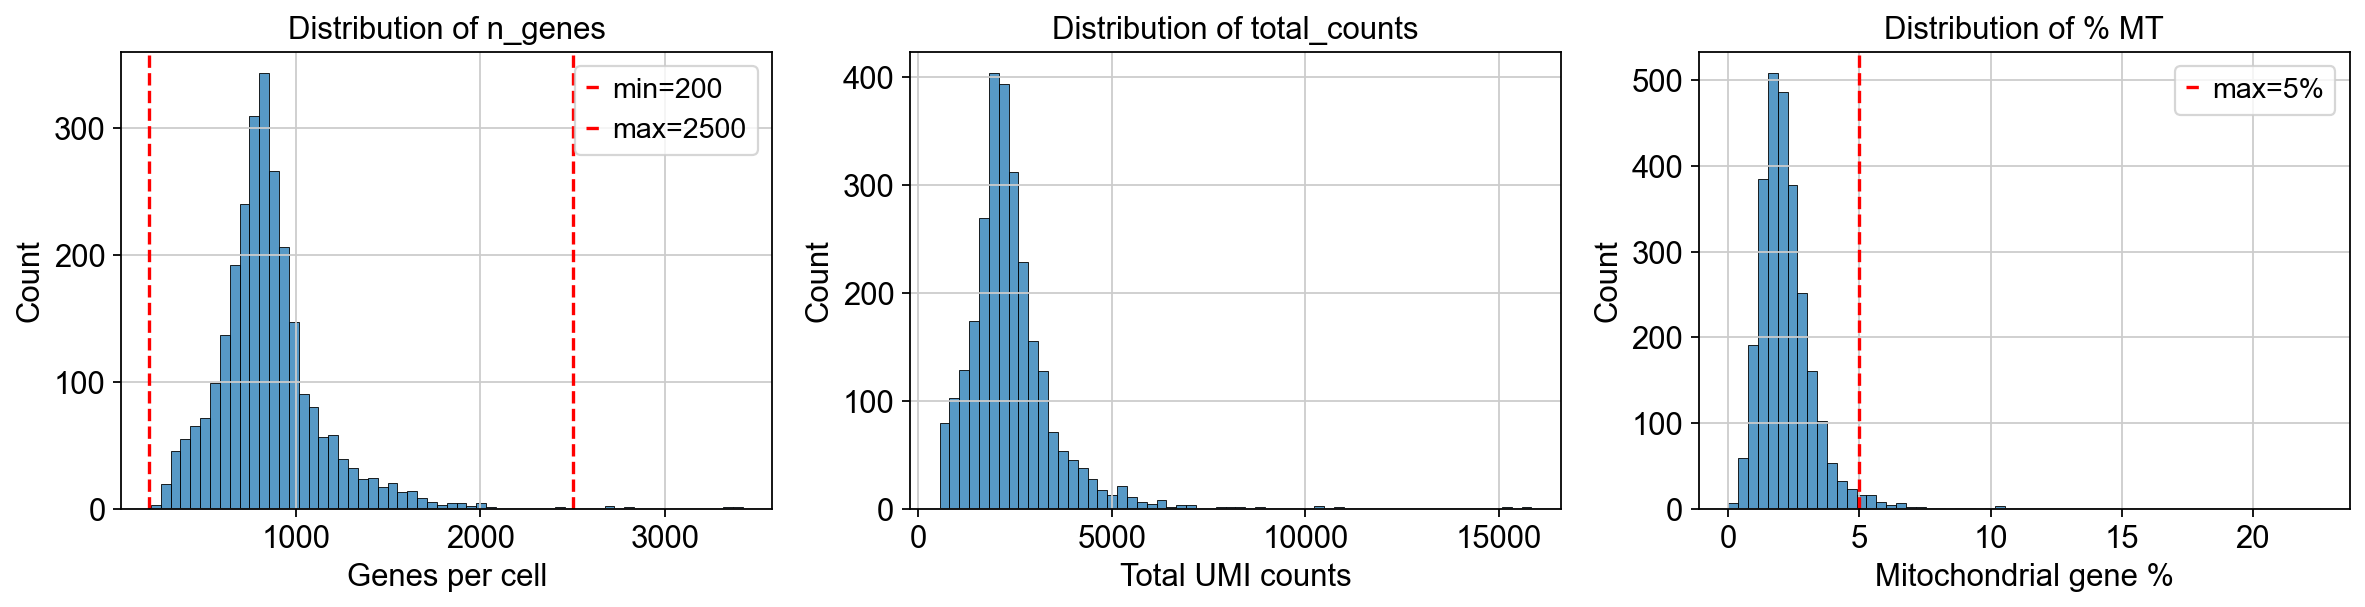

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# n_genes_by_counts
sns.histplot(adata.obs["n_genes_by_counts"], bins=60, ax=axes[0], kde=False)
axes[0].axvline(config.QC_MIN_GENES, color="red", linestyle="--", label=f"min={config.QC_MIN_GENES}")
axes[0].axvline(config.QC_MAX_GENES, color="red", linestyle="--", label=f"max={config.QC_MAX_GENES}")
axes[0].set_xlabel("Genes per cell")
axes[0].set_title("Distribution of n_genes")
axes[0].legend()

# total_counts
sns.histplot(adata.obs["total_counts"], bins=60, ax=axes[1], kde=False)
axes[1].set_xlabel("Total UMI counts")
axes[1].set_title("Distribution of total_counts")

# pct_counts_mt
sns.histplot(adata.obs["pct_counts_mt"], bins=60, ax=axes[2], kde=False)
axes[2].axvline(config.QC_MAX_PCT_MT, color="red", linestyle="--", label=f"max={config.QC_MAX_PCT_MT}%")
axes[2].set_xlabel("Mitochondrial gene %")
axes[2].set_title("Distribution of % MT")
axes[2].legend()

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "01_qc_before_filter.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 过滤低质量细胞

In [8]:
print(f"过滤前: {adata.n_obs} 细胞 × {adata.n_vars} 基因")

过滤前: 2700 细胞 × 32738 基因


In [9]:
# 5.1 过滤细胞
adata = adata[adata.obs.n_genes_by_counts > config.QC_MIN_GENES, :]
adata = adata[adata.obs.n_genes_by_counts < config.QC_MAX_GENES, :]
adata = adata[adata.obs.pct_counts_mt < config.QC_MAX_PCT_MT, :]

In [11]:
# 5.2 过滤基因（至少在 min_cells 个细胞中表达）
sc.pp.filter_genes(adata, min_cells=config.QC_MIN_CELLS)


In [12]:
print(f"过滤后: {adata.n_obs} 细胞 × {adata.n_vars} 基因")

过滤后: 2638 细胞 × 13656 基因


## 6. 标准化与高变基因选择

In [13]:
# 6.1 总 UMI 数归一化到 1e4，然后 log1p 变换
# 这是单细胞标准做法：消除文库大小差异
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:10)


In [14]:
# 6.2 标记高变基因（Highly Variable Genes）
# 后续 PCA 和聚类只使用这些基因，降低噪声
sc.pp.highly_variable_genes(adata, n_top_genes=config.N_TOP_GENES, subset=True)

print(f"高变基因选择后: {adata.n_obs} 细胞 × {adata.n_vars} 基因")
print(f"高变基因比例: {adata.n_vars / 13714 * 100:.1f}%")

extracting highly variable genes
    finished (0:00:07)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
高变基因选择后: 2638 细胞 × 2000 基因
高变基因比例: 14.6%


In [15]:
# 6.3 保存高变基因列表（后续 marker 分析会用到全部基因）
# 注意：subset=True 后 adata 只保留高变基因，但原始基因信息在 adata.raw 中
adata.raw = adata  # 保存一份完整的 log1p 数据到 raw

## 7. 降维（PCA）

d:\miniconda3\envs\rna\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:08)
前10个主成分的方差贡献率:
[0.0253 0.0126 0.0101 0.0087 0.0051 0.0028 0.0025 0.002  0.002  0.0019]


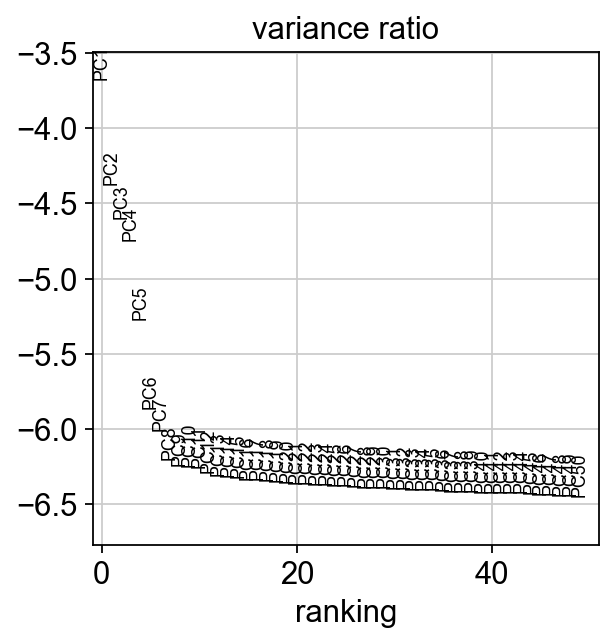

In [16]:
# 使用高变基因进行 PCA
sc.pp.scale(adata, max_value=10)  # 缩放到单位方差，截断极端值
sc.tl.pca(adata, svd_solver="arpack", n_comps=config.N_PCS)

# 查看方差贡献
print(f"前10个主成分的方差贡献率:")
print(adata.uns["pca"]["variance_ratio"][:10].round(4))

# 可视化 PCA
sc.pl.pca_variance_ratio(adata, n_pcs=config.N_PCS, log=True,
                         save="_variance_ratio.png")

## 8. 保存清洗后的数据

In [17]:
out_path = save_h5ad(adata, "pbmc3k_qc_normalized.h5ad")
print(f"数据已保存至: {out_path}")

数据已保存至: E:\project\scRNA-topo-pipeline\data\processed\pbmc3k_qc_normalized.h5ad


In [18]:
# 同时导出一份质控统计表
qc_stats = adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]]
qc_stats.to_csv(config.TABLES_DIR / "01_qc_stats.csv")
print(f"质控统计表已保存至: {config.TABLES_DIR / '01_qc_stats.csv'}")


质控统计表已保存至: E:\project\scRNA-topo-pipeline\results\tables\01_qc_stats.csv
